## Data Spatial Visualization

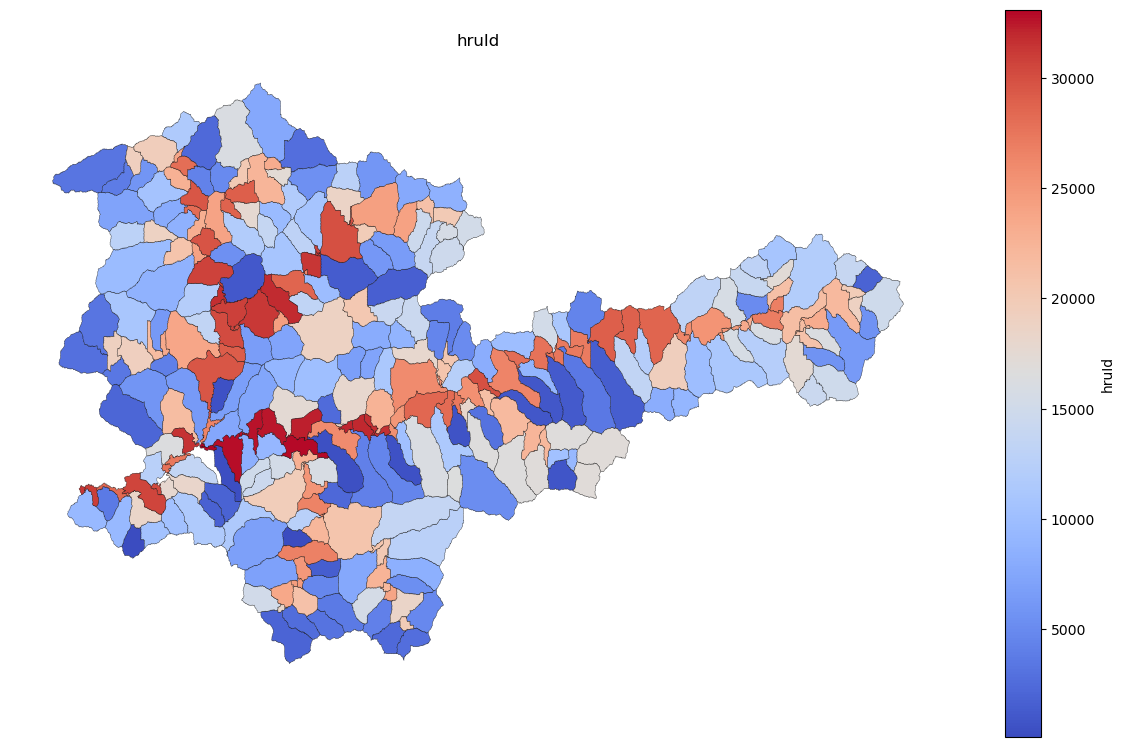

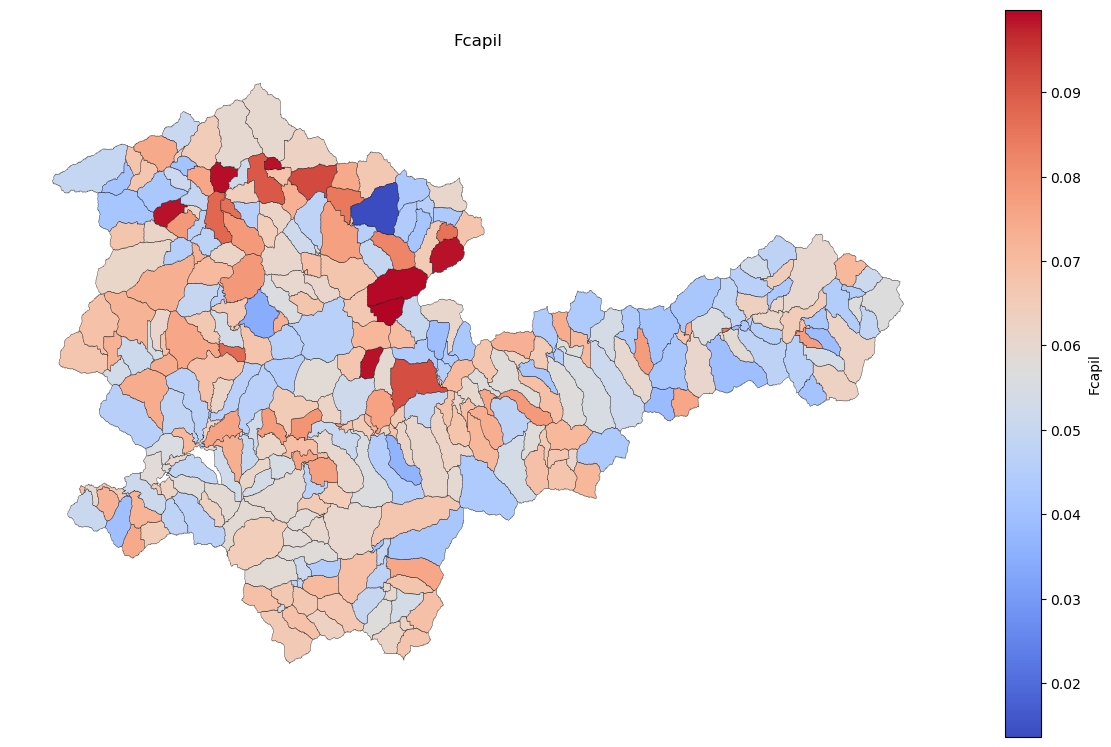

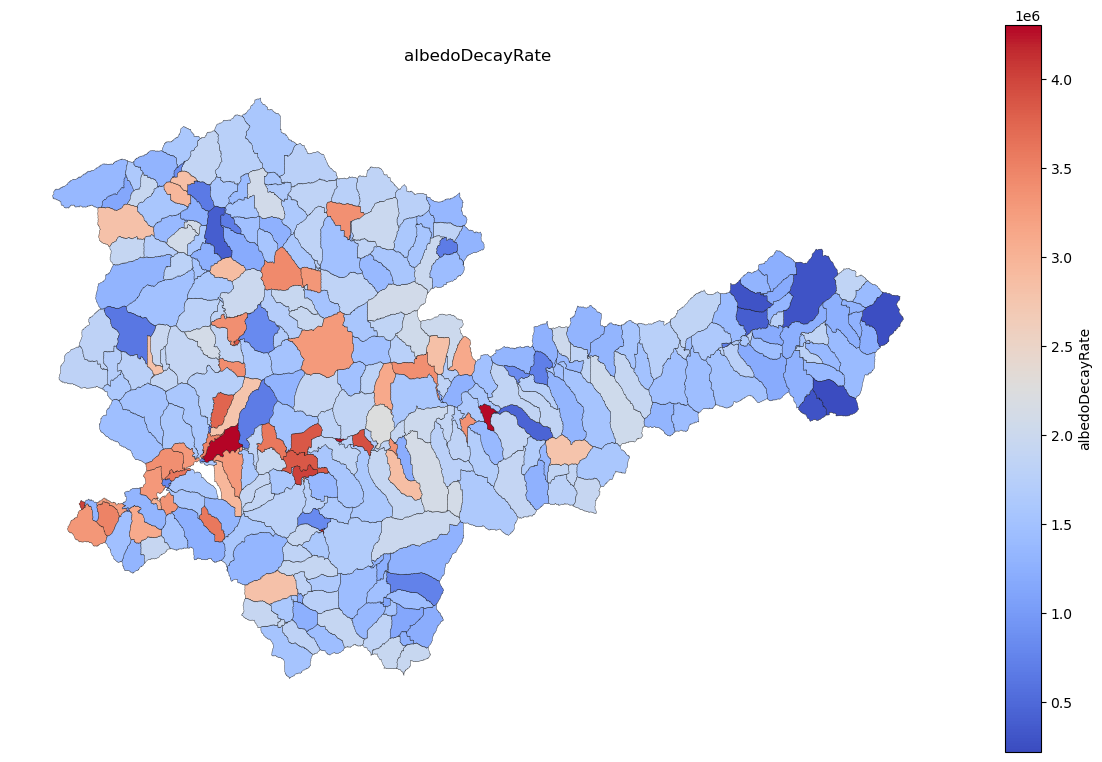

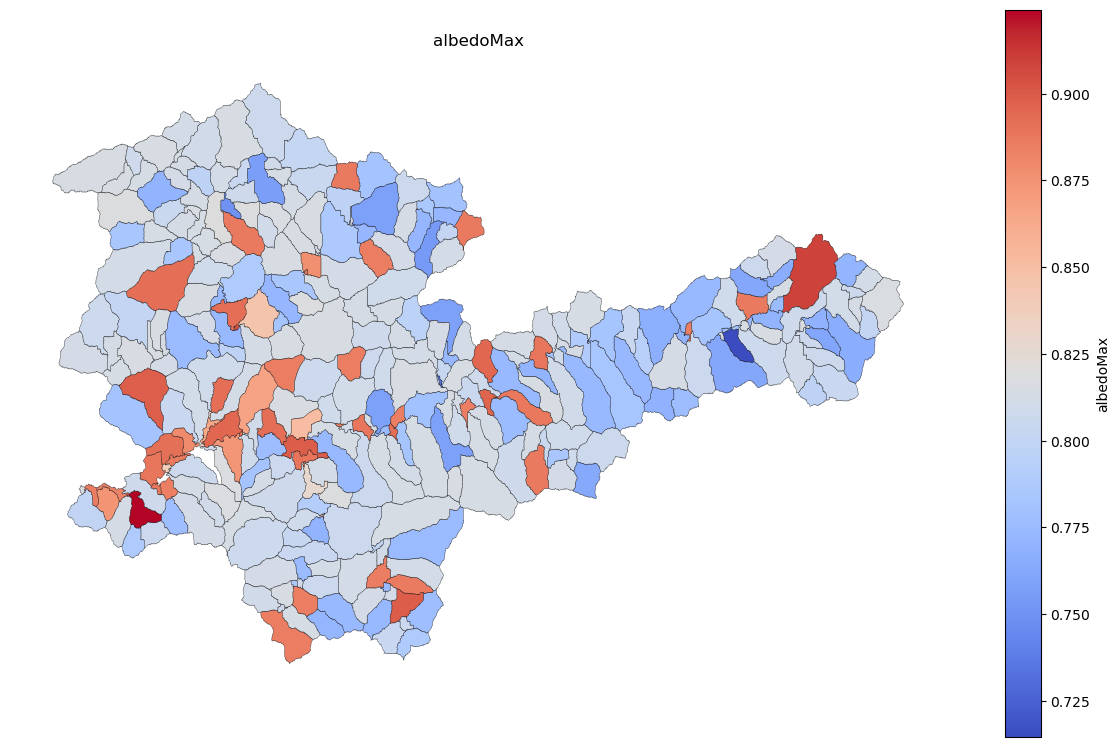

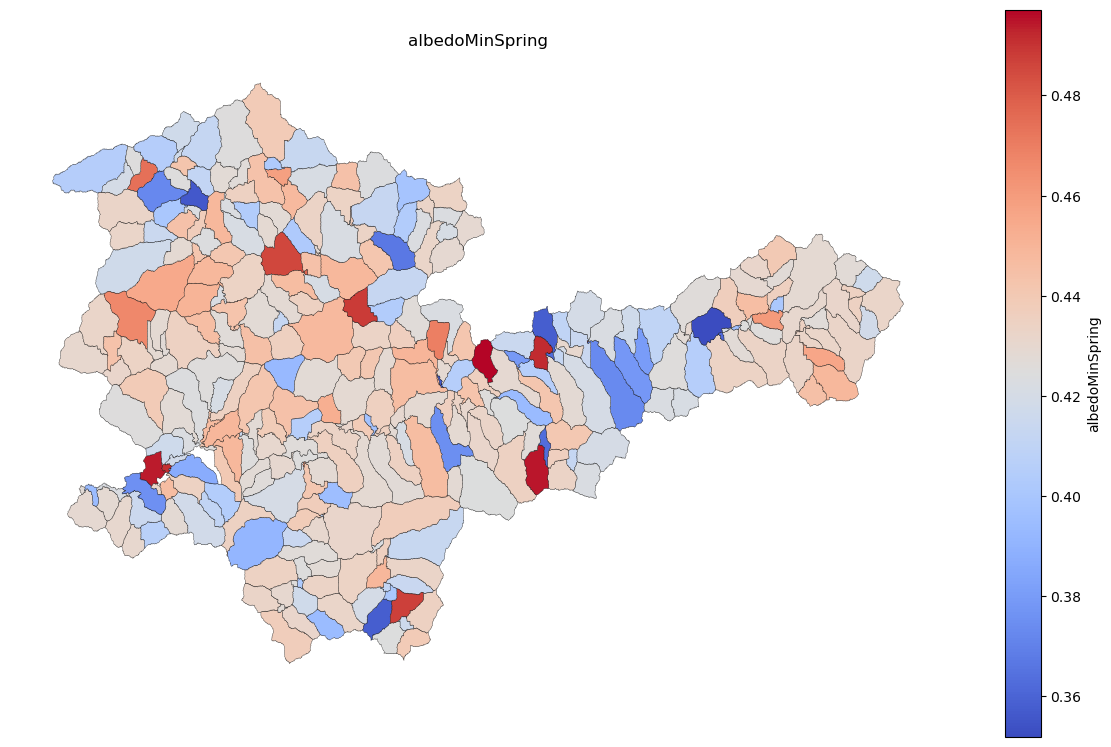

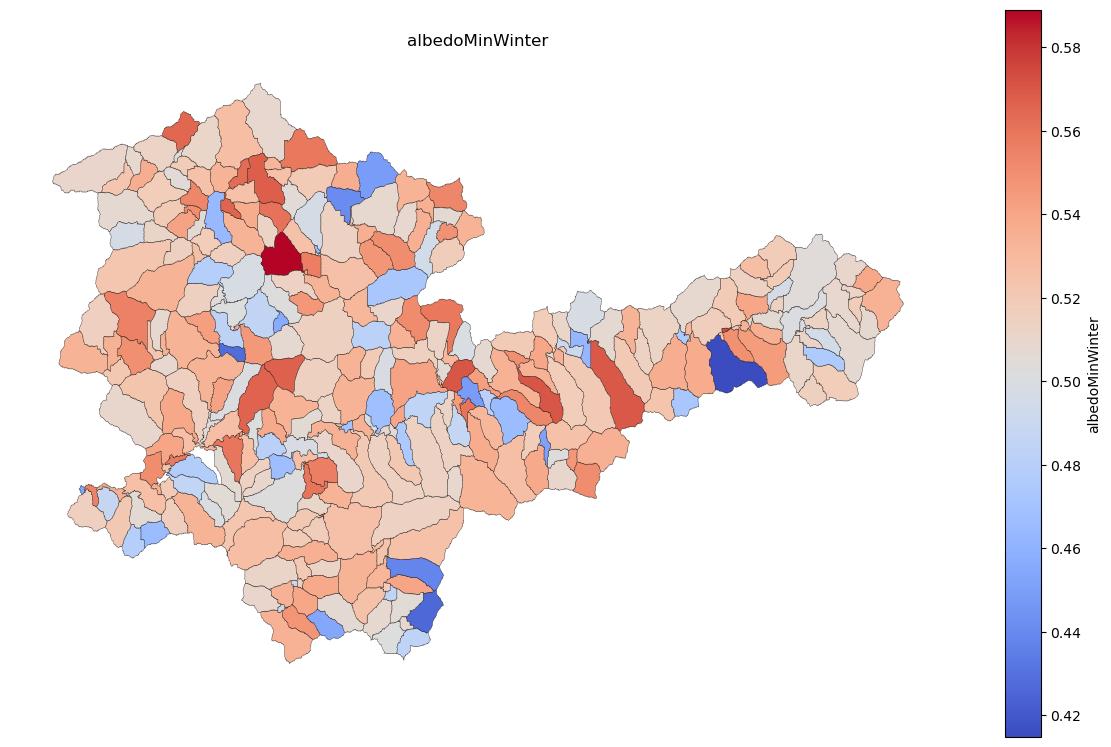

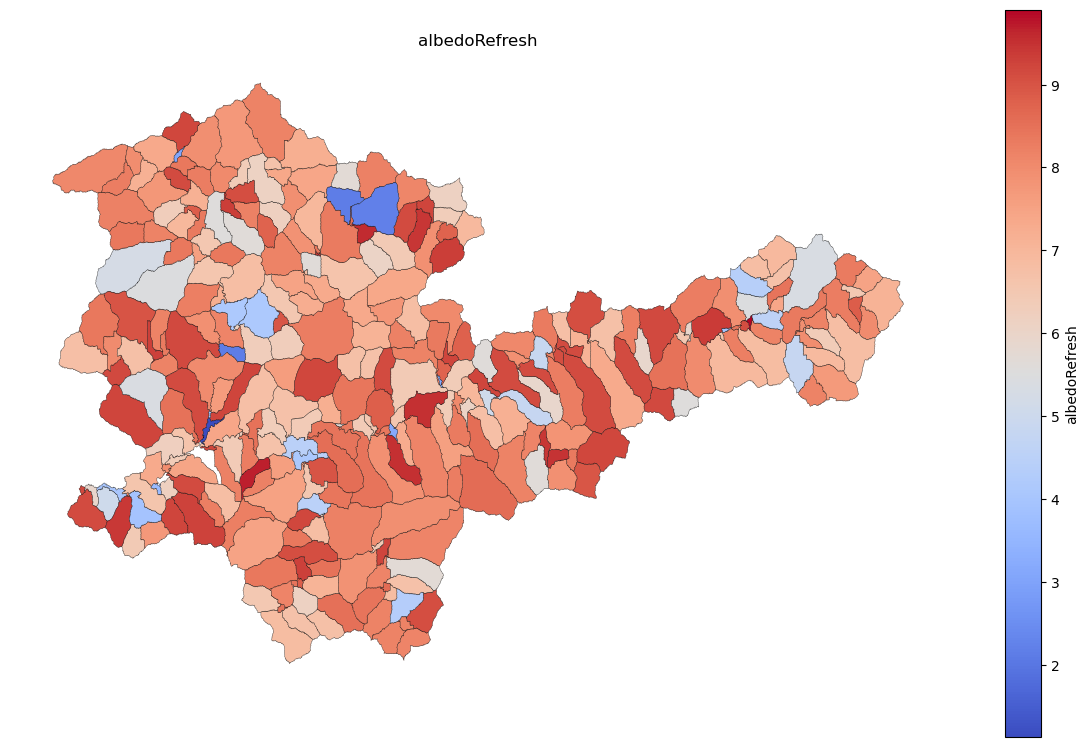

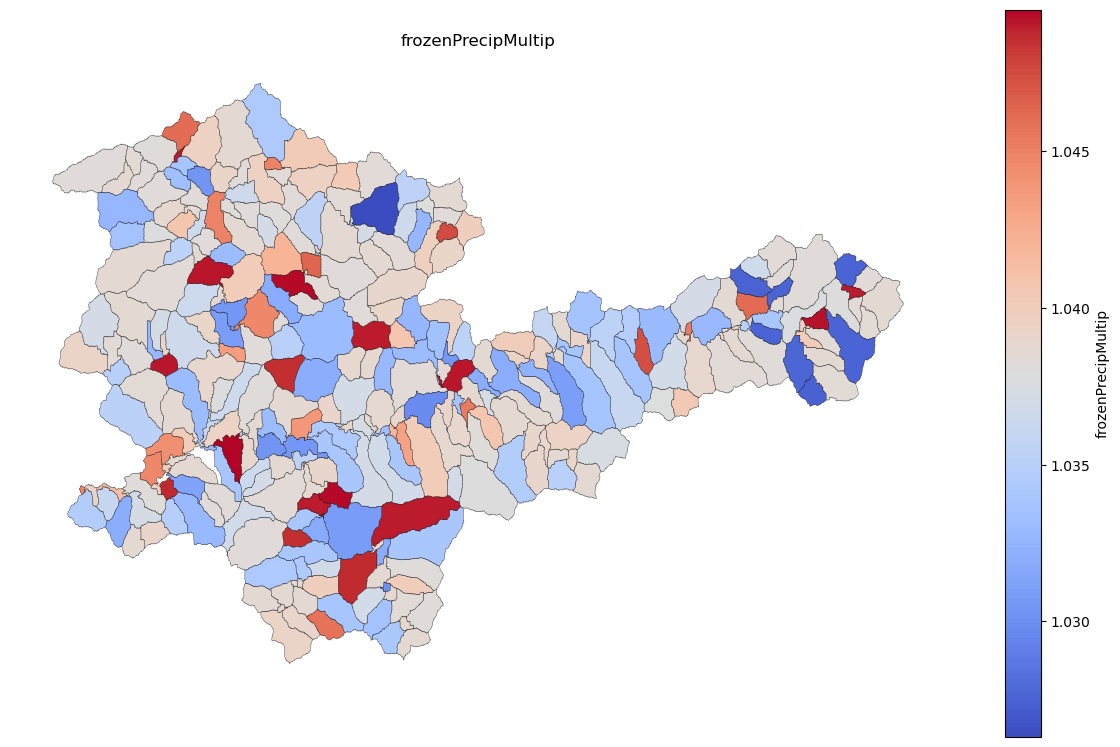

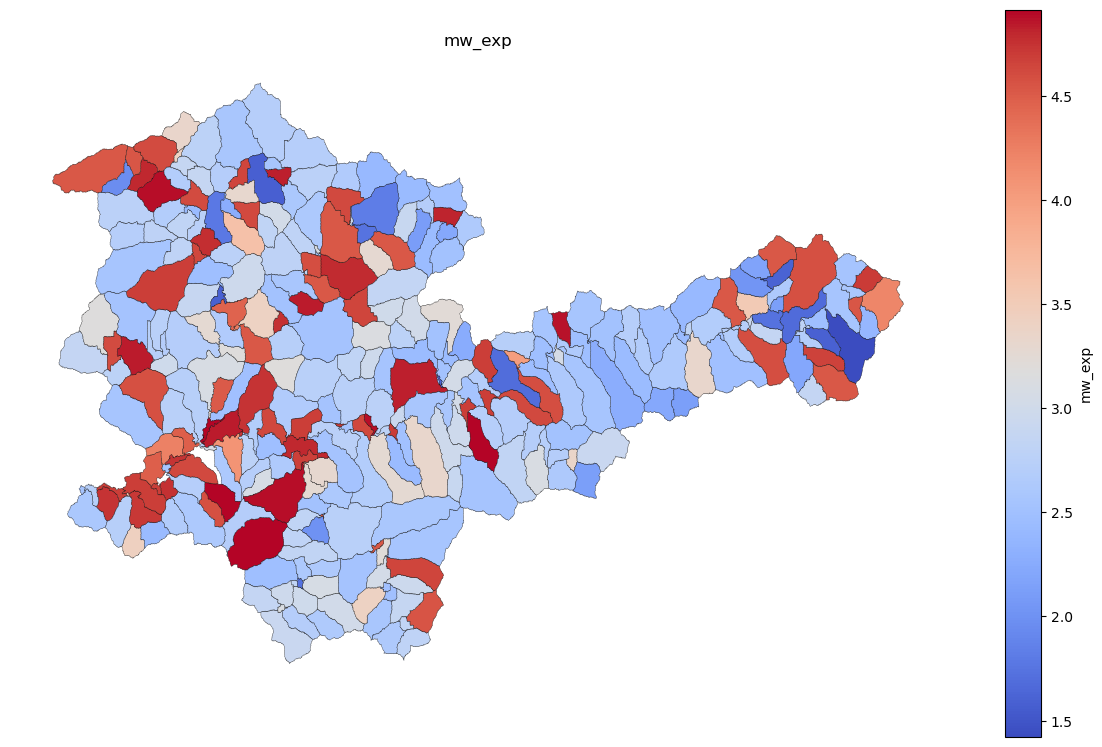

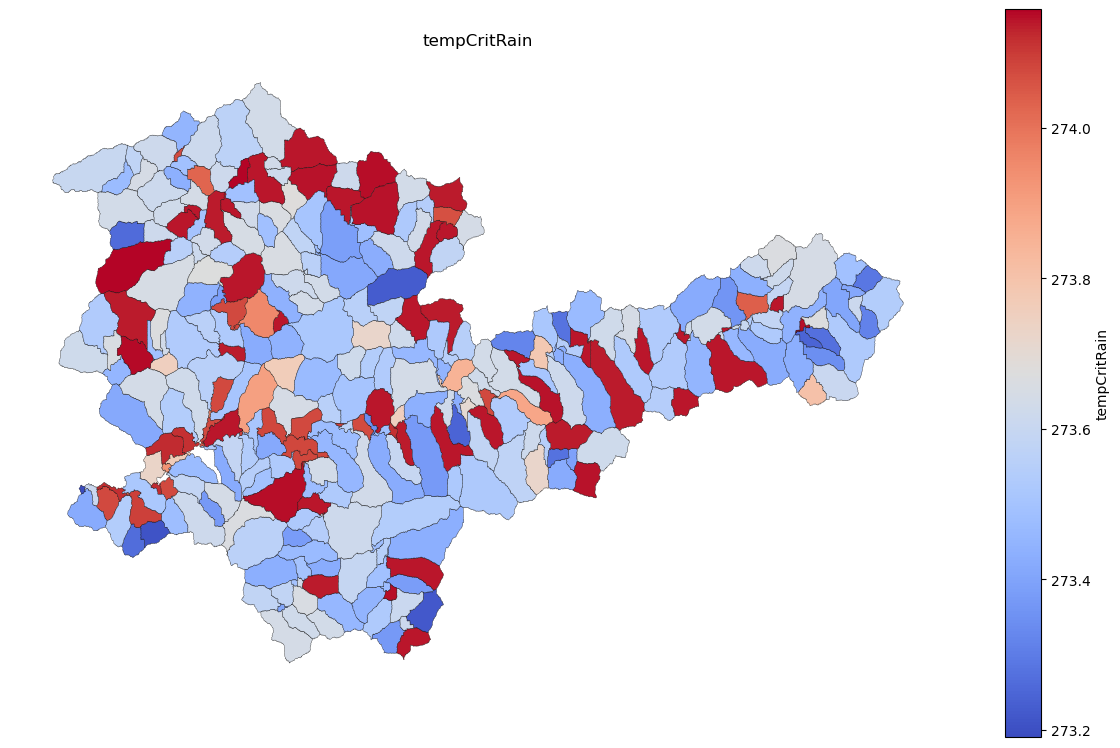

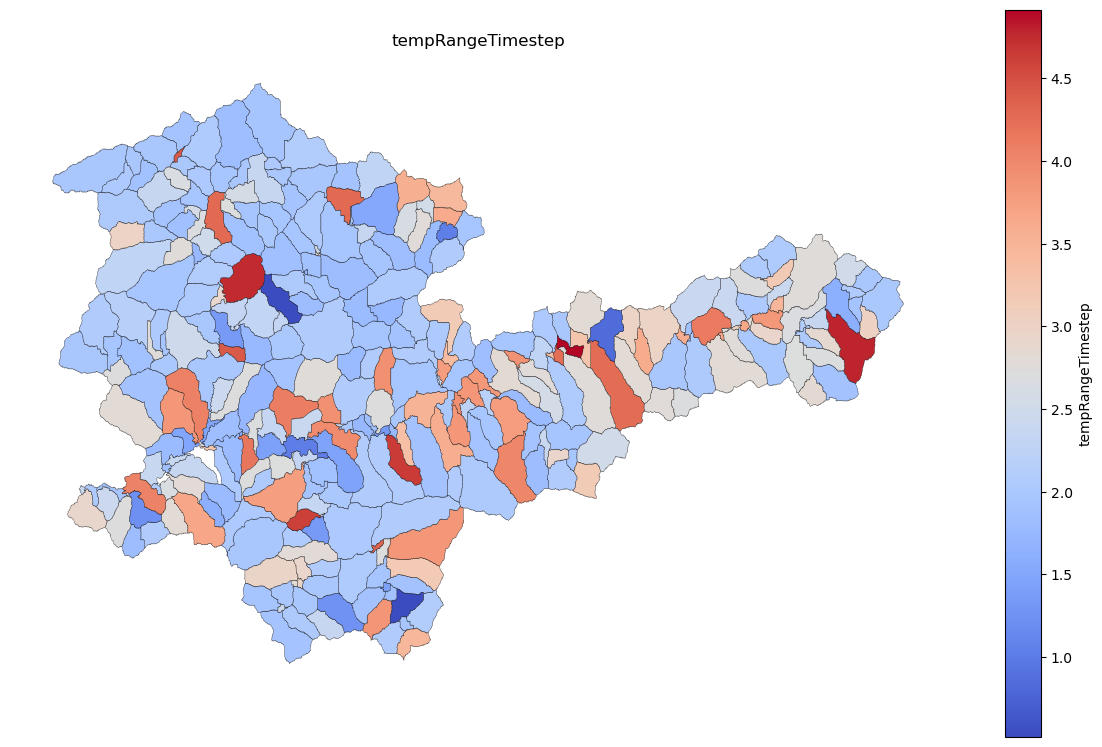

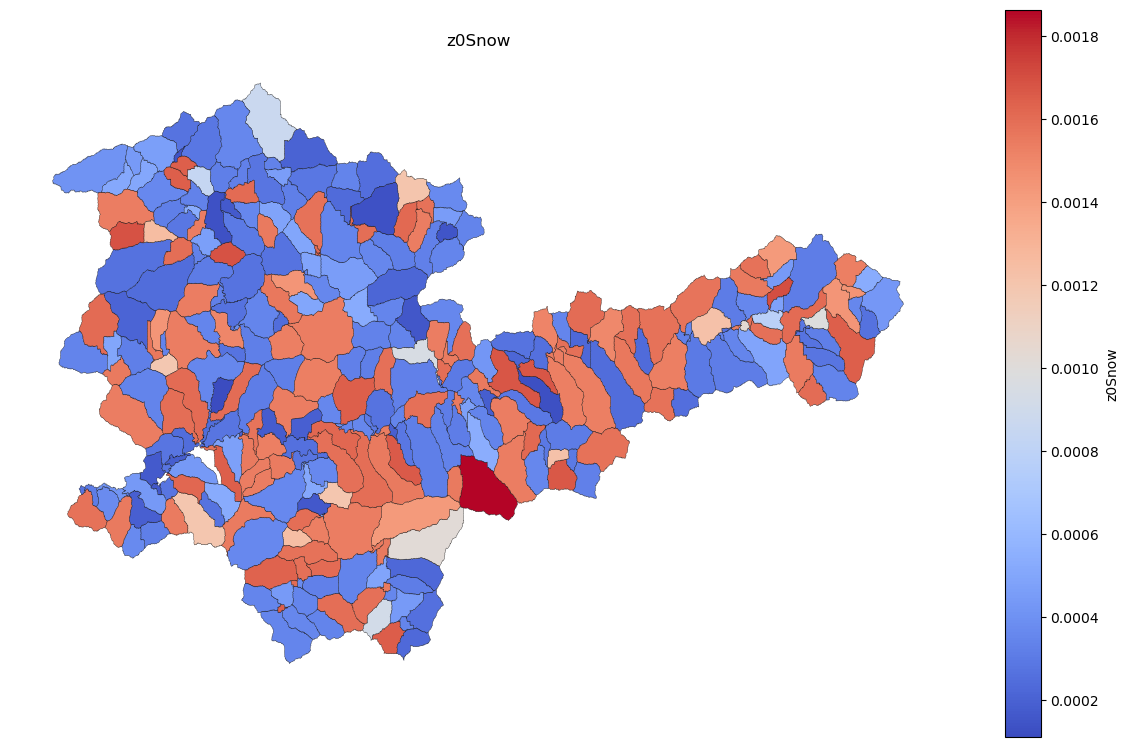

In [1]:
import geopandas as gpd
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

def plot_spatial_variables(
    nc_path,                      # Path to your NetCDF (e.g. 'attributes.nc')
    gpkg_path,                    # Path to your GeoPackage
    gpkg_layer=None,              # Optional layer name in the GPKG
    gpkg_id_field="HRU_ID",       # ID field in the GPKG
    netcdf_id_field="hruId",      # Which var in the NetCDF is your "index"?
                                   # (e.g. 'hruId' or 'gruId')
    mapping_csv=None,             # Optional CSV for hru↔gru mapping
    mapping_hru_field="hruId",    # Column in mapping_csv for HRU IDs
    mapping_gru_field="gruId",    # Column in mapping_csv for GRU IDs
    skip_vars=None,               # Vars never to map (e.g. coords)
    output_dir=None,              # Where to save PNGs (or None to show)
    figsize=(10, 8),
    cmap="viridis",
):
    """
    1) If netcdf_id_field is a GRU var and mapping_csv is given, each 1-D GRU field
       is first joined to mapping_csv and expanded to every HRU.
    2) Otherwise each 1-D hruId field is plotted directly.
    """
    ds = xr.open_dataset(nc_path)
    gdf = gpd.read_file(gpkg_path, layer=gpkg_layer) if gpkg_layer \
          else gpd.read_file(gpkg_path)

    if netcdf_id_field not in ds:
        raise KeyError(f"NetCDF has no variable '{netcdf_id_field}'")

    # default skip-list
    skip = set(skip_vars or ["longitude", "latitude", "index"])
    skip.add(netcdf_id_field)

    # if GRU-indexed and mapping provided, load mapping once
    map_df = None
    if mapping_csv and netcdf_id_field == mapping_gru_field:
        map_df = (
            pd.read_csv(mapping_csv)
              [[mapping_hru_field, mapping_gru_field]]
              .drop_duplicates()
        )
        # ensure types line up
        map_df[mapping_hru_field] = map_df[mapping_hru_field].astype(int)
        map_df[mapping_gru_field] = map_df[mapping_gru_field].astype(int)

    # prep output folder
    if output_dir:
        outdir = Path(output_dir)
        outdir.mkdir(parents=True, exist_ok=True)

    for var in ds.data_vars:
        if var in skip:
            continue
        da = ds[var]
        # only 1-D vars on the index dim
        if da.ndim != 1 or netcdf_id_field not in da.dims:
            continue

        # pull raw array and replace -9999 with np.nan
        vals = da.values
        vals = np.where(vals == -9999, np.nan, vals)
        ids  = ds[netcdf_id_field].values.astype(int)

        # --- branch: GRU -> HRU expansion ---
        if map_df is not None:
            # build the GRU-var table
            gru_df = pd.DataFrame({mapping_gru_field: ids, var: vals})
            # join --> one row per HRU
            df_hru = (map_df
                      .merge(gru_df, on=mapping_gru_field, how="left"))
            # final table for merging to gdf
            merge_df = df_hru.rename(
                columns={mapping_hru_field: gpkg_id_field}
            )[[gpkg_id_field, var]]

        else:
            # direct HRU table - add 1 to match GRU_ID
            merge_df = pd.DataFrame({gpkg_id_field: ids + 1, var: vals})

        # merge into copy of polygons
        tmp = gdf.copy()
        tmp[gpkg_id_field] = tmp[gpkg_id_field].astype(merge_df[gpkg_id_field].dtype)
        plot_gdf = tmp.merge(merge_df, on=gpkg_id_field, how="left")

        # make sure it worked
        if var not in plot_gdf:
            print(f"⚠️   '{var}' failed to merge → skipping")
            continue

        # choropleth
        fig, ax = plt.subplots(figsize=figsize)
        vmin, vmax = plot_gdf[var].min(), plot_gdf[var].max()
        plot_gdf.plot(
            column      = var,
            cmap        = cmap,
            vmin        = vmin,
            vmax        = vmax,
            legend      = True,
            legend_kwds = {"label": var, "shrink":0.75},
            ax          = ax,
            edgecolor   = "black",
            linewidth   = 0.2,
        )
        ax.set_title(var)
        ax.axis("off")
        plt.tight_layout()
        plt.show()

        if output_dir:
            fig.savefig(outdir/f"{var}.png", dpi=300)
        else:
            plt.show()
        plt.close(fig)

catchment = 'chena'
base_dir = f'/anvil/projects/x-ees240082/users/dcasson/gpep/{catchment}/summa/settings/'
nc_path = f'/anvil/projects/x-ees240082/users/dcasson/gpep/{catchment}/summa/TSS_trialParams.nc'
gpkg_path = f'/anvil/projects/x-ees240082/users/dcasson/gpep/{catchment}/gis/{catchment}_tdx.gpkg'
mapping_csv = f'/anvil/projects/x-ees240082/users/dcasson/gpep/{catchment}/summa/hru_gru_mapping.csv'

output_dir = "maps_output"


# ——— Example usage ———
plot_spatial_variables(
    nc_path=nc_path,
    gpkg_path=gpkg_path,
    gpkg_layer=None,
    gpkg_id_field="GRU_ID",
    netcdf_id_field="hru",
    mapping_csv=mapping_csv,
    mapping_hru_field="index",
    mapping_gru_field="gruId",
    output_dir=output_dir,    # set to None if you just want to show inline
    figsize=(12, 10),
    cmap="coolwarm"
)

In [2]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

def plot_from_tabular(
    txt_path,                     # e.g. 'Bow_avgForcing.txt'
    gpkg_path,                    # your HRU GeoPackage
    gpkg_layer=None,
    gpkg_id_field="GRU_ID",       # HRU_ID in the GPKG
    txt_id_field="hruID",         # column in the TXT (but really GRU IDs!)
    mapping_csv=None,             # HRU↔GRU mapping CSV
    mapping_hru_field="gruId",    # HRU column in mapping_csv
    mapping_gru_field="index",    # GRU column in mapping_csv
    skip_cols=None,               # columns to skip (e.g. coords)
    output_dir=None,
    figsize=(10,8),
    cmap="viridis",
):
    """
    If mapping_csv is given, txt_id_field is treated as a GRU index:
      → the script will expand every GRU‐row to all HRUs via your mapping file.
    Otherwise, it joins txt_id_field directly to HRU polygons.
    """
    df = pd.read_csv(txt_path, delim_whitespace=True)
    gdf = gpd.read_file(gpkg_path, layer=gpkg_layer) if gpkg_layer \
          else gpd.read_file(gpkg_path)

    # sanity checks
    if txt_id_field not in df.columns:
        raise KeyError(f"TXT has no column '{txt_id_field}'")
    if gpkg_id_field not in gdf.columns:
        raise KeyError(f"GPKG has no field '{gpkg_id_field}'")

    skip = set(skip_cols or ["lat","lon"])
    skip.add(txt_id_field)

    # load mapping if needed
    map_df = None
    if mapping_csv:
        map_df = (
            pd.read_csv(mapping_csv)
              [[mapping_hru_field, mapping_gru_field]]
              .drop_duplicates()
        )
        map_df[mapping_hru_field] = map_df[mapping_hru_field].astype(int)
        map_df[mapping_gru_field] = map_df[mapping_gru_field].astype(int)

    if output_dir:
        outdir = Path(output_dir)
        outdir.mkdir(parents=True, exist_ok=True)

    for col in df.columns:
        if col in skip:
            continue

        # build the per-HRU table
        if map_df is not None:
            # treat txt_id_field as GRU
            tmp = df.rename(columns={txt_id_field: mapping_gru_field})
            gru_df = tmp[[mapping_gru_field, col]]
            hru_df = map_df.merge(gru_df, on=mapping_gru_field, how="left")
            merge_df = hru_df.rename(
                columns={mapping_hru_field: gpkg_id_field}
            )[[gpkg_id_field, col]]

        else:
            # treat txt_id_field as HRU
            merge_df = df[[txt_id_field, col]].rename(
                columns={txt_id_field: gpkg_id_field}
            )

        # join & plot
        tmpg = gdf.copy()
        tmpg[gpkg_id_field] = tmpg[gpkg_id_field].astype(merge_df[gpkg_id_field].dtype)
        plot_gdf = tmpg.merge(merge_df, on=gpkg_id_field, how="left")

        if col not in plot_gdf:
            print(f"⚠️   '{col}' failed to merge → skipping")
            continue

        fig, ax = plt.subplots(figsize=figsize)
        vmin, vmax = plot_gdf[col].min(), plot_gdf[col].max()
        plot_gdf.plot(
            column      = col,
            cmap        = cmap,
            vmin        = vmin,
            vmax        = vmax,
            legend      = True,
            legend_kwds = {"label": col, "shrink":0.75},
            ax          = ax,
            edgecolor   = "black",
            linewidth   = 0.2,
        )
        ax.set_title(col)
        ax.axis("off")
        plt.tight_layout()

        if output_dir:
            fig.savefig(outdir/f"{col}.png", dpi=300)
        else:
            plt.show()
        plt.close(fig)

In [3]:


# for your .txt forcing (indexed by GRU!)
plot_from_tabular(
    txt_path        = "/anvil/projects/x-ees240082/users/nicolas-vasquez/sharedFolder/01_Dave/Bow_avgForcing.txt",
    gpkg_path       = gpkg_path,
    txt_id_field    = "hruID",               # this is actually GRU!
    mapping_csv     = "/anvil/projects/x-ees240082/users/dcasson/gpep/bow/summa/hru_gru_mapping.csv",
    output_dir      = "forcing_maps_test"
)

/tmp/ipykernel_764948/4194543958.py:29: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(txt_path, delim_whitespace=True)


In [5]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import math

def plot_netcdf_cdfs_combined(nc_files, exclude_vars=None, output_dir=None, combined_filename="all_vars_cdf.png"):
    """
    Create a single figure with ECDFs for every variable in the given NetCDF files.

    Parameters
    ----------
    nc_files : list of str or Path
        Paths to one or more NetCDF files to compare.
    exclude_vars : list of str, optional
        Variable names to skip (e.g. ['time', 'lat', 'lon']). Default: None.
    output_dir : str or Path, optional
        If provided, the figure is saved as <output_dir>/<combined_filename>.
        Otherwise, the figure is shown interactively.
    combined_filename : str, optional
        Filename for the saved figure. Default is "all_vars_cdf.png".
    """
    exclude = set(exclude_vars or [])

    # 1) Get list of variables to plot from first file
    with xr.open_dataset(nc_files[0]) as ds0:
        vars_to_plot = [v for v in ds0.data_vars if v not in exclude]

    n = len(vars_to_plot)
    if n == 0:
        print("No variables to plot.")
        return

    # 2) Determine subplot grid
    ncols = min(3, n)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(ncols * 5, nrows * 4),
                             squeeze=False)
    axes_flat = axes.flatten()

    # 3) Build each subplot
    for i, var in enumerate(vars_to_plot):
        ax = axes_flat[i]
        for fp in nc_files:
            with xr.open_dataset(fp) as ds:
                if var not in ds:
                    continue
                data = ds[var].values.ravel()
                mask = (~np.isnan(data)) & (data != -9999)
                data = data[mask]
                if data.size == 0:
                    continue
                sorted_vals = np.sort(data)
                ecdf = np.arange(1, sorted_vals.size + 1) / sorted_vals.size
                label = Path(fp).stem
                ax.plot(sorted_vals, ecdf, label=label)

        ax.set_title(var)
        ax.set_xlabel(var)
        ax.set_ylabel("ECDF")
        ax.grid(True)
        ax.legend(fontsize="small", loc="best")

    # 4) Hide any unused axes
    for j in range(n, len(axes_flat)):
        fig.delaxes(axes_flat[j])

    fig.tight_layout()

    # 5) Save or show
    if output_dir:
        outdir = Path(output_dir)
        outdir.mkdir(parents=True, exist_ok=True)
        fig.savefig(outdir / combined_filename, bbox_inches="tight")
        plt.show()
        plt.close(fig)
    else:
        plt.show()

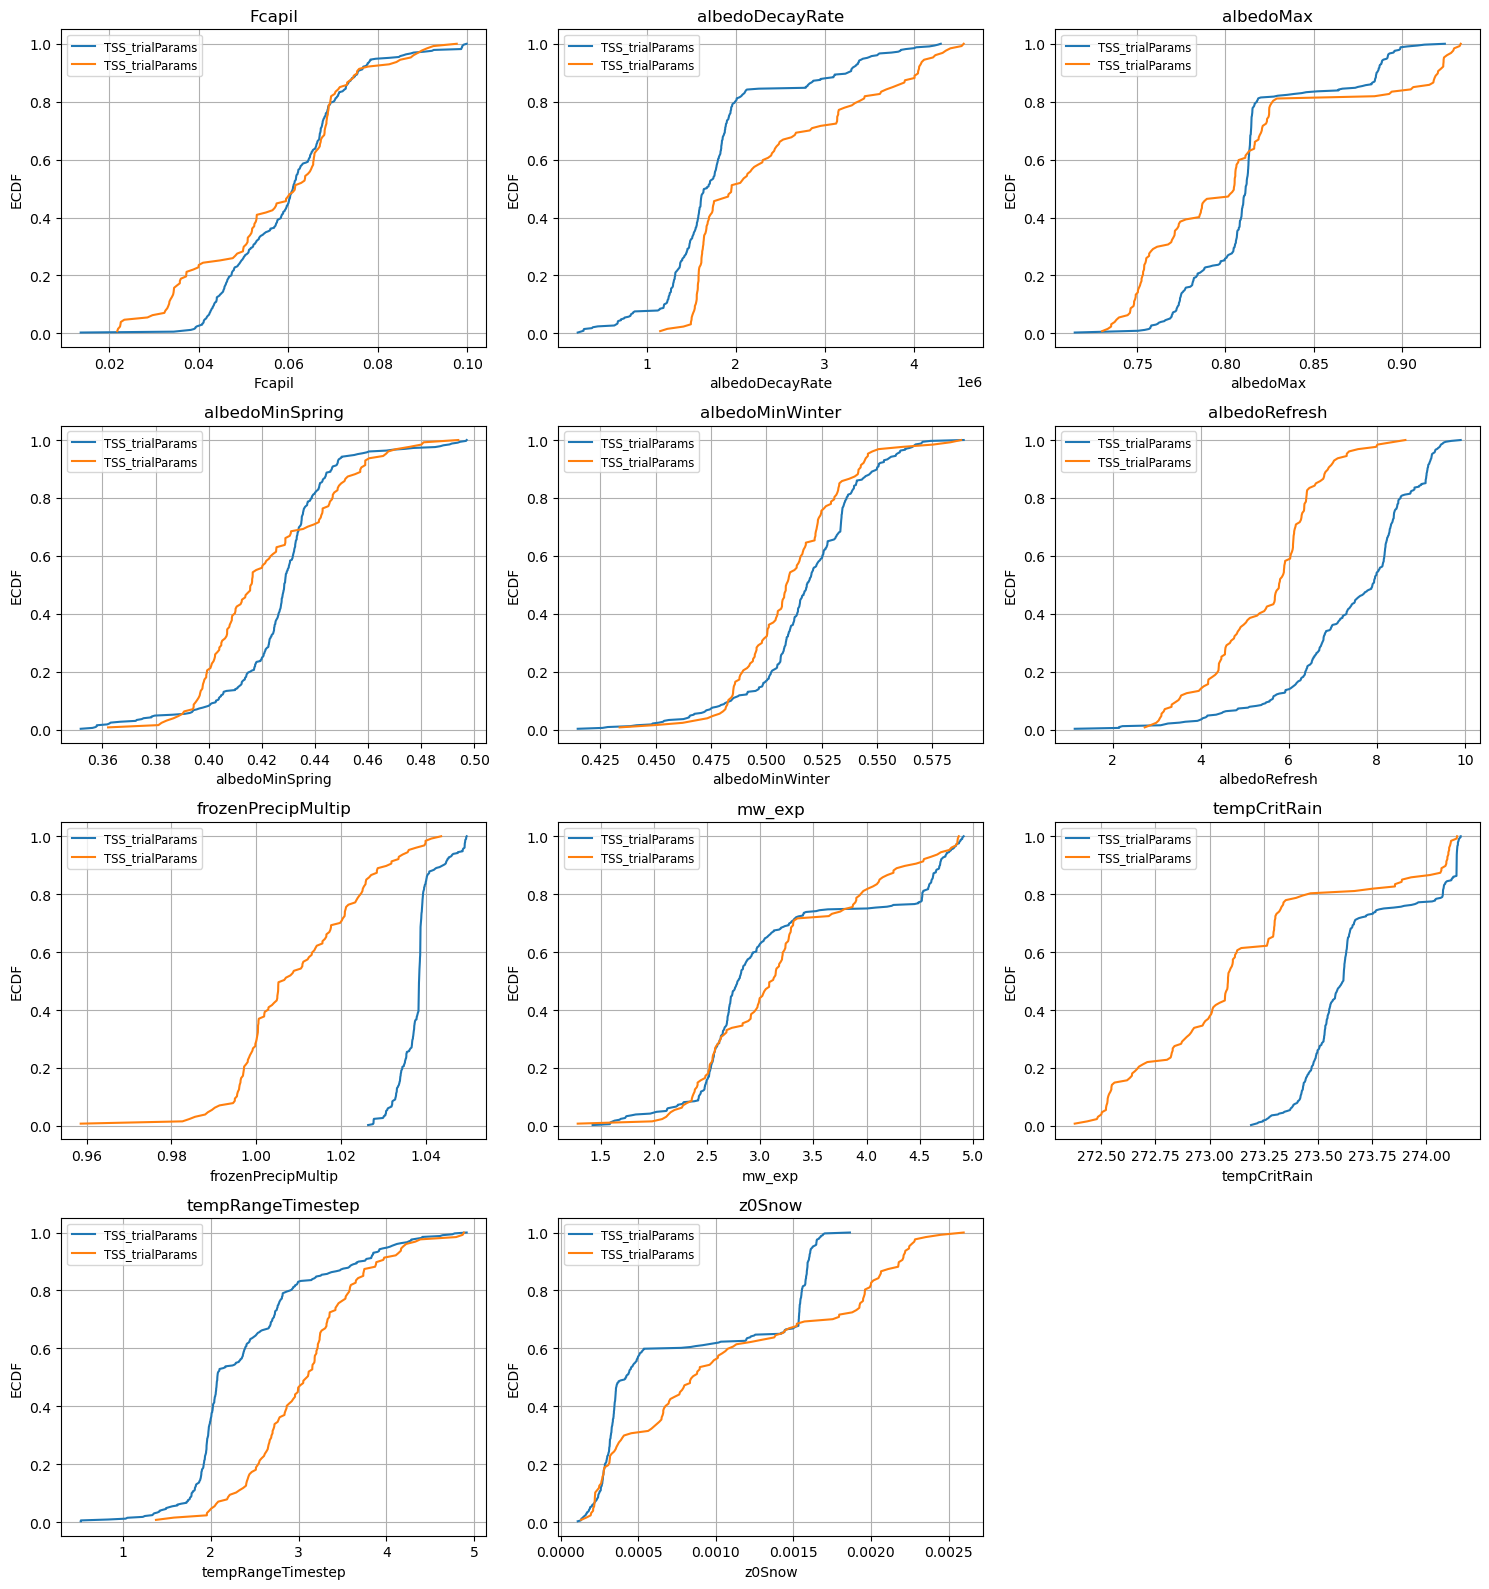

In [6]:
files = [
    '/anvil/projects/x-ees240082/users/dcasson/gpep/chena/summa/TSS_trialParams.nc',
    '/anvil/projects/x-ees240082/users/dcasson/gpep/tuolumne/summa/TSS_trialParams.nc',
]
plot_netcdf_cdfs_combined(
    files,
    exclude_vars=['time','lat','lon','hruId'],
    output_dir='cdf_plots_corr'
)